<a href="https://colab.research.google.com/github/saadbinather/Multi-Factor-Stock-Forecasting-FW/blob/main/extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install pandas-datareader

In [ ]:
!pip install git+https://github.com/raphi6/pandas-datareader.git@ea66d6b981554f9d0262038aef2106dda7138316

  Cloning https://github.com/raphi6/pandas-datareader.git (to revision ea66d6b981554f9d0262038aef2106dda7138316) to /tmp/pip-req-build-2gkoghp1
  Running command git clone --filter=blob:none --quiet https://github.com/raphi6/pandas-datareader.git /tmp/pip-req-build-2gkoghp1
  Running command git rev-parse -q --verify 'sha^ea66d6b981554f9d0262038aef2106dda7138316'
  Running command git fetch -q https://github.com/raphi6/pandas-datareader.git ea66d6b981554f9d0262038aef2106dda7138316
  Running command git checkout -q ea66d6b981554f9d0262038aef2106dda7138316
  Resolved https://github.com/raphi6/pandas-datareader.git to commit ea66d6b981554f9d0262038aef2106dda7138316
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error w

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.layers import Bidirectional




In [ ]:


companies_dict = OrderedDict({
    'Amazon':'AMZN',
    'Apple':'AAPL',
    'Nike':'NKE',
    'Google':'GOOGL',
    'META':'META'
})

In [ ]:
def create_sequences_multivariate(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])

        y.append(data[i, 3])  # Only predict Close price

    return np.array(X), np.array(y)

In [ ]:
results = []
plot_data = {}


for company_name, ticker in companies_dict.items():


    df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(df)  # Shape: (n_samples, 5)

    seq_length = 30
    # Modified to handle multiple features
    X, y = create_sequences_multivariate(scaled_data, seq_length)

    # Define split date
    split_date = "2022-12-01"

    # Get index position of split
    split_index = df.index.get_loc(split_date)

    # Because of sequences (30 days), adjust split
    split_index = split_index - seq_length

    # Split sequences
    X_train = X[:split_index]
    y_train = y[:split_index]

    X_test = X[split_index:]
    y_test = y[split_index:]

    # Get correct test dates
    test_dates = df.index[seq_length + split_index:]

    # Modified model for multivariate input
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),  # (30, 5)
        LSTM(50, return_sequences=True),  # Added return_sequences for better learning
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    predictions = model.predict(X_test, verbose=0)

    # For inverse transform, we need to reconstruct the full feature set
    # We'll use the last known values for other features
    predictions_full = np.zeros((len(predictions), 5))

    # Get the last sequence's last day values for other features
    last_sequences = X_test[:, -1, :]  # Last day of each test sequence


    predictions_full[:, :] = last_sequences

    # Replace Close price (index 3) with predictions
    predictions_full[:, 3] = predictions.flatten()

    # Inverse transform to get actual values
    predictions_actual = scaler.inverse_transform(predictions_full)


    predictions_close = predictions_actual[:, 3].reshape(-1, 1)


    y_test_full = np.zeros((len(y_test), 5))
    # Use the corresponding last day values for other features
    y_test_full[:, :] = last_sequences
    y_test_full[:, 3] = y_test.flatten()
    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    plot_data[company_name] = (test_dates, y_test_actual, predictions_close)

/tmp/ipykernel_1015/2187326674.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2187326674.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2187326674.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2187326674.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp

In [ ]:

results_df = pd.DataFrame(results)
print("\nFinal Results:")
print(results_df)



Final Results:
  Company  RMSE   MAE
0  Amazon  5.28  4.77
1   Apple  5.70  4.71
2    Nike  5.57  5.04
3  Google  2.92  2.43
4    META  5.17  4.21


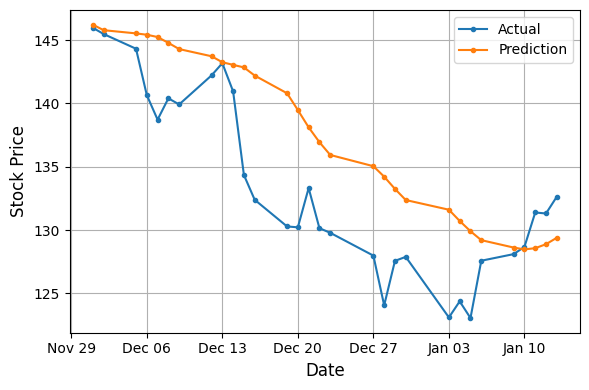

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
bilstm_results = []
bilstm_plot_data = {}

for company_name, ticker in companies_dict.items():

    print(f"Processing (BiLSTM) {company_name}...")

    df = yf.download(ticker, start="2022-01-01", end="2023-01-01")
    # Select all features (Open, High, Low, Close, Volume)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(df)  # Shape: (n_samples, 5)

    seq_length = 30
    # Use multivariate sequence creation function
    X, y = create_sequences_multivariate(scaled_data, seq_length)

    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)
    split_index = split_index - seq_length

    X_train = X[:split_index]
    y_train = y[:split_index]

    X_test = X[split_index:]
    y_test = y[split_index:]

    test_dates = df.index[seq_length + split_index:]

    # BiLSTM model for multivariate input
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),  # (30, 5)

        # First Bidirectional LSTM layer with return_sequences=True
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.2),

        # Second Bidirectional LSTM layer
        Bidirectional(LSTM(32)),
        Dropout(0.2),

        # Output layer for single value (Close price)
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    predictions = model.predict(X_test, verbose=0)

    # For inverse transform, we need to reconstruct the full feature set
    # Get the last sequence's last day values for other features
    last_sequences = X_test[:, -1, :]  # Last day of each test sequence (shape: n_test_samples, 5)

    # Create full feature array for predictions
    predictions_full = np.zeros((len(predictions), 5))
    predictions_full[:, :] = last_sequences  # Fill with last known values
    predictions_full[:, 3] = predictions.flatten()  # Replace Close price (index 3) with predictions

    # Inverse transform to get actual values
    predictions_actual = scaler.inverse_transform(predictions_full)

    # Extract just the Close price predictions
    predictions_close = predictions_actual[:, 3].reshape(-1, 1)

    # For actual y_test values (Close prices)
    y_test_full = np.zeros((len(y_test), 5))
    y_test_full[:, :] = last_sequences  # Use same last known values for other features
    y_test_full[:, 3] = y_test.flatten()  # Replace with actual Close prices
    y_test_actual_full = scaler.inverse_transform(y_test_full)
    y_test_actual = y_test_actual_full[:, 3].reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_close))
    mae = mean_absolute_error(y_test_actual, predictions_close)

    bilstm_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    bilstm_plot_data[company_name] = (test_dates, y_test_actual, predictions_close)

/tmp/ipykernel_1015/4282112762.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Processing (BiLSTM) Amazon...



/tmp/ipykernel_1015/4282112762.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Processing (BiLSTM) Apple...


/tmp/ipykernel_1015/4282112762.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Processing (BiLSTM) Nike...



/tmp/ipykernel_1015/4282112762.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Processing (BiLSTM) Google...



/tmp/ipykernel_1015/4282112762.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Processing (BiLSTM) META...


In [ ]:
bilstmresults_df = pd.DataFrame(bilstm_results)
print("\nFinal Results:")
print(bilstmresults_df)




Final Results:
  Company  RMSE   MAE
0  Amazon  7.05  6.61
1   Apple  6.07  5.25
2    Nike  6.24  5.33
3  Google  3.02  2.76
4    META  3.99  2.97


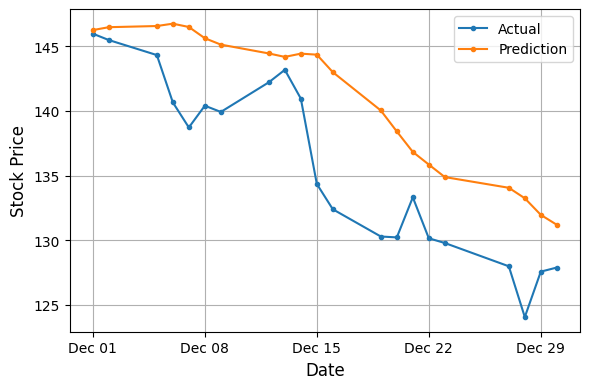

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = bilstm_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
df.head()

/tmp/ipykernel_1015/3354507720.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2022-01-03,335.903992,338.424192,334.564497,335.665840,14537900
2022-01-04,333.909637,340.418556,329.285918,337.303021,15998000
2022-01-05,321.645905,333.145657,321.318457,330.426971,20564500
2022-01-06,329.871307,336.529082,320.207157,320.306385,27962800
2022-01-07,329.206543,334.375967,326.319198,330.149128,14722000


In [ ]:


df.columns = df.columns.get_level_values(0)

# Create price movement feature
df['Price_Movement'] = df['Close'] - df['Open']

df = df.dropna()

# Define split date
split_date = "2022-12-01"

# Get index position
split_index = df.index.get_loc(split_date)

# Features & Target
X = df[['Open','High','Low','Volume','Price_Movement']]
y = df['Close']

# Date-based split (NO shuffle for time series)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [ ]:
# Cell 1: Data preparation for all companies
company_data = {}

for company_name, ticker in companies_dict.items():
    print(f"Preparing data for {company_name} ({ticker})...")

    # Download data
    df = yf.download(ticker, start="2022-01-01", end="2023-01-15")

    # Flatten columns
    df.columns = df.columns.get_level_values(0)

    # Create price movement feature
    df['Price_Movement'] = df['Close'] - df['Open']
    df = df.dropna()

    # Define split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)

    # Features & Target
    X = df[['Open', 'High', 'Low', 'Volume', 'Price_Movement']]
    y = df['Close']

    # Date-based split
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Test dates
    test_dates = df.index[split_index:]

    # Store all data
    company_data[company_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'test_dates': test_dates,
        'ticker': ticker,
        'df': df  # Original dataframe bhi store karo
    }



/tmp/ipykernel_1015/103335880.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/103335880.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/103335880.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/103335880.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipy

Preparing data for Amazon (AMZN)...
Preparing data for Apple (AAPL)...
Preparing data for Nike (NKE)...
Preparing data for Google (GOOGL)...
Preparing data for META (META)...


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler

ridge_results = []
ridge_plot_data = {}

for company_name, ticker in companies_dict.items():


    # Download and prepare data
    df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)
    df['Target'] = df['Close'].shift(-1)
    # Create price movement feature
    df['Price_Movement'] = df['Close'] - df['Open']
    df = df.dropna()

    # Define split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)

    # Features & Target
    X = df[['Open', 'High', 'Low', 'Volume', 'Price_Movement']]
    y = df['Close']

    # Date-based split (NO shuffle for time series)
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Get test dates for plotting
    test_dates = df.index[split_index:]

    # Scale features (Ridge benefits from feature scaling)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    # Train Ridge model
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train_scaled)

    # Make predictions
    pred_scaled = ridge.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    ridge_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2)
    })

    # Store plot data
    ridge_plot_data[company_name] = (test_dates, y_test_actual, predictions)



/tmp/ipykernel_1015/2937184084.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2937184084.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2937184084.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2937184084.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed


In [ ]:
ridge_results_df = pd.DataFrame(ridge_results)
print("\nRidge Regression Results:")
print(ridge_results_df)


Ridge Regression Results:
  Company  RMSE   MAE
0  Amazon  0.90  0.84
1   Apple  0.70  0.56
2    Nike  0.32  0.26
3  Google  0.69  0.64
4    META  1.91  1.85


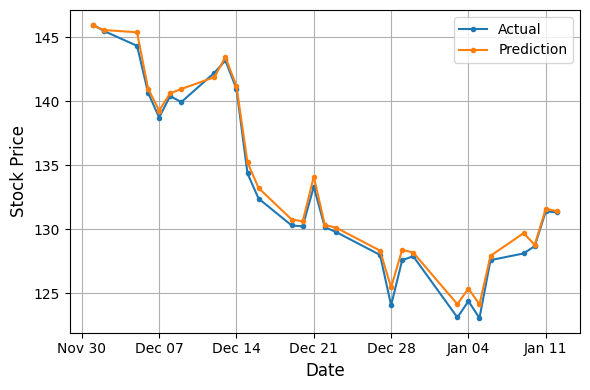

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = ridge_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
# Cell: Artificial Neural Network (ANN) for Stock Price Prediction
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import yfinance as yf

ann_results = []
ann_plot_data = {}

for company_name, ticker in companies_dict.items():


    # Download and prepare data
    df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    # Create price movement feature
    df['Price_Movement'] = df['Close'] - df['Open']
    df = df.dropna()

    # Define split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)

    # Features & Target
    X = df[['Open', 'High', 'Low', 'Volume', 'Price_Movement']]
    y = df['Close']

    # Date-based split (NO shuffle for time series)
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Get test dates for plotting
    test_dates = df.index[split_index:]

    # Scale features (important for neural networks)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    # Build ANN model
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    # Compile model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='loss', patience=10, verbose=0, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=100,
        batch_size=16,
        verbose=0,
        callbacks=[early_stop]
    )

    # Make predictions
    pred_scaled = model.predict(X_test_scaled, verbose=0)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Store results
    ann_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),

    })

    # Store plot data
    ann_plot_data[company_name] = (test_dates, y_test_actual, predictions)



/tmp/ipykernel_1015/2440130662.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2440130662.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2440130662.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/2440130662.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed


In [ ]:
ann_results_df = pd.DataFrame(ann_results)
print("\nANN Results:")
print(ann_results_df)


ANN Results:
  Company  RMSE   MAE
0  Amazon  5.58  4.74
1   Apple  3.96  3.11
2    Nike  4.26  3.97
3  Google  1.74  1.32
4    META  2.96  2.42


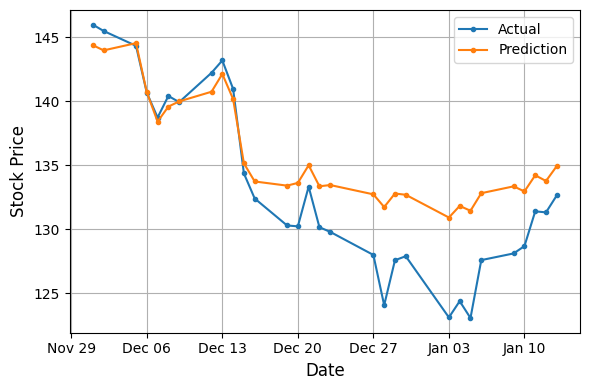

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = ann_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
# Cell: Random Forest for Stock Price Prediction
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import yfinance as yf

rf_results = []
rf_plot_data = {}

for company_name, ticker in companies_dict.items():


    # Download and prepare data
    df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    # Create price movement feature
    df['Price_Movement'] = df['Close'] - df['Open']
    df = df.dropna()

    # Define split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)

    # Features & Target
    X = df[['Open', 'High', 'Low', 'Volume', 'Price_Movement']]
    y = df['Close']

    # Date-based split (NO shuffle for time series)
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Get test dates for plotting
    test_dates = df.index[split_index:]

    # Scale features (optional for Random Forest, but keeping for consistency)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    # Train Random Forest model
    rf = RandomForestRegressor(
        n_estimators=100,        # Number of trees
        max_depth=10,             # Maximum depth of trees
        min_samples_split=5,      # Minimum samples to split a node
        min_samples_leaf=2,       # Minimum samples at leaf node
        random_state=42,
        n_jobs=-1                  # Use all processors
    )
    rf.fit(X_train_scaled, y_train_scaled)

    # Make predictions
    pred_scaled = rf.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Feature importance
    feature_importance = dict(zip(X.columns, rf.feature_importances_))
    top_feature = max(feature_importance, key=feature_importance.get)

    # Store results
    rf_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),

    })

    # Store plot data
    rf_plot_data[company_name] = (test_dates, y_test_actual, predictions)


/tmp/ipykernel_1015/1735956938.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/1735956938.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/1735956938.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/1735956938.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed


In [ ]:
rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df)

  Company  RMSE   MAE
0  Amazon  3.76  2.95
1   Apple  2.54  1.76
2    Nike  0.80  0.61
3  Google  1.21  0.95
4    META  2.77  2.19


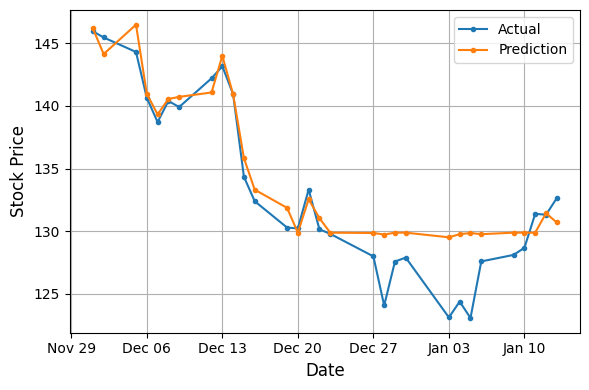

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


for company_name in plot_data:
    if company_name=='Apple':
      dates, actual, predicted = rf_plot_data["Apple"]

      plt.figure(figsize=(6,4))

      # Plot lines with markers
      plt.plot(dates, actual, label="Actual", marker='o', markersize=3)
      plt.plot(dates, predicted, label="Prediction", marker='o', markersize=3)

      # Labels
      plt.xlabel("Date", fontsize=12)
      plt.ylabel("Stock Price", fontsize=12)

      ax = plt.gca()
      ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.grid(True)
      plt.legend(fontsize=10)
      plt.tight_layout()


      # ✅ Then show
      plt.show()

      # Close the figure
      plt.close()

In [ ]:
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler


xgb_results = []
xgb_plot_data = {}

for company_name, ticker in companies_dict.items():


    # Download and prepare data
    df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    # Create price movement feature
    df['Price_Movement'] = df['Close'] - df['Open']
    df = df.dropna()

    # Define split date
    split_date = "2022-12-01"
    split_index = df.index.get_loc(split_date)

    # Features & Target
    X = df[['Open', 'High', 'Low', 'Volume', 'Price_Movement']]
    y = df['Close']

    # Date-based split (NO shuffle for time series)
    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Get test dates for plotting
    test_dates = df.index[split_index:]

    # Scale features (optional for XGBoost, but keeping for consistency)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    # Train XGBoost model
    xgb = XGBRegressor(
        n_estimators=200,        # Number of boosting rounds
        max_depth=6,              # Maximum tree depth
        learning_rate=0.1,        # Step size shrinkage
        subsample=0.8,            # Subsample ratio of training data
        colsample_bytree=0.8,     # Subsample ratio of columns
        random_state=42,
        n_jobs=-1                  # Use all processors
    )

    xgb.fit(
        X_train_scaled,
        y_train_scaled,
        eval_set=[(X_test_scaled, y_test_scaled)],
        verbose=False
    )

    # Make predictions
    pred_scaled = xgb.predict(X_test_scaled)
    predictions = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    y_test_actual = y_test.values

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)

    # Feature importance
    feature_importance = dict(zip(X.columns, xgb.feature_importances_))
    top_feature = max(feature_importance, key=feature_importance.get)

    # Store results
    xgb_results.append({
        "Company": company_name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
    })

    # Store plot data
    xgb_plot_data[company_name] = (test_dates, y_test_actual, predictions)

/tmp/ipykernel_1015/1529300742.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/1529300742.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/1529300742.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1015/1529300742.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-15")
[*********************100%***********************]  1 of 1 completed


In [ ]:
xgb_results_df = pd.DataFrame(xgb_results)
print("\XGB Results:")
print(xgb_results_df)

\XGB Results:
  Company  RMSE   MAE
0  Amazon  2.40  1.90
1   Apple  1.86  1.41
2    Nike  0.74  0.55
3  Google  1.17  0.93
4    META  1.81  1.33


<>:2: SyntaxWarning: invalid escape sequence '\X'
<>:2: SyntaxWarning: invalid escape sequence '\X'
/tmp/ipykernel_1015/667668806.py:2: SyntaxWarning: invalid escape sequence '\X'
  print("\XGB Results:")


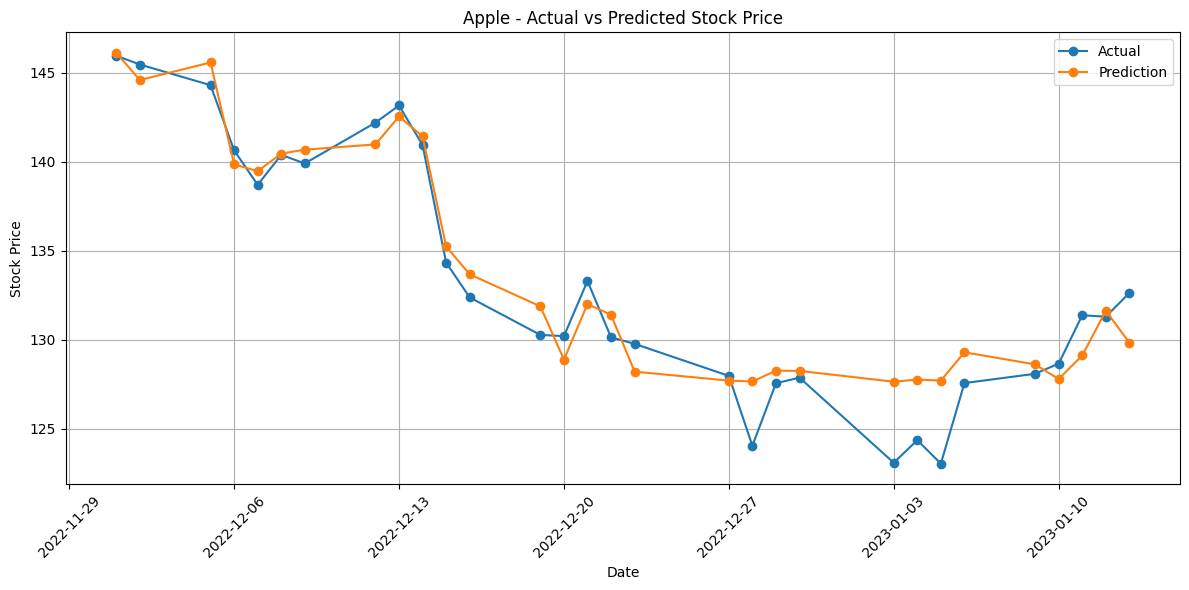

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

for company_name in xgb_plot_data:
  if company_name=='Apple':
    dates, actual, predicted = xgb_plot_data[company_name]
    plt.figure(figsize=(12,6))

    # Line chart with markers
    plt.plot(dates, actual, label="Actual", marker='o')
    plt.plot(dates, predicted, label="Prediction", marker='o')

    plt.title(f"{company_name} - Actual vs Predicted Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")

    # Set x-axis to show ticks every 7 days
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()